# Dual-Language Fake News Detection 
### Arabic + English |  Rich Visualizations

## 1. Import Libraries

In [1]:
import os, gc, warnings, re, string, time, joblib
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Embedding, LSTM, Bidirectional,
                                     Conv1D, MaxPooling1D, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.18.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
try:
    from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, AdamWeightDecay
    TRANSFORMERS_AVAILABLE = True
    print('Transformers available')
except Exception as e:
    TRANSFORMERS_AVAILABLE = False
    print('Transformers not available')

Transformers available


## 2. Load Datasets

In [3]:
df_en = pd.read_csv('/kaggle/input/fake-news-classification/WELFake_Dataset.csv')
print('English shape:', df_en.shape)
df_en.head(2)

English shape: (72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1


In [4]:
df_ar = pd.read_csv('/kaggle/input/datasets/mohamedmahmoud1775/arabic-fake-news-processed-data/arabic_fake_news_processed.csv')
print('Arabic shape:', df_ar.shape)
df_ar.head(2)

Arabic shape: (100000, 3)


,label,Article_content,cleaned_text
0,credible,بوينغ توصي شركات الطيران بوقف رحلات طائرات 777...,بوينغ وصى شركة طير وقف رحلة طاءرات حت اصدار تو...
1,credible,الدحيل والريان في قمة مباريات دوري اليد متابعة...,الدحيل ري قمه مباريات دوري يد متابع رمض مسعد ا...


## 3. Preprocessing

In [5]:
def clean_english(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation.replace("'", '')))
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = ' '.join(text.split())
    tokens = word_tokenize(text)
    stop = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop and len(t) > 1]
    lem = WordNetLemmatizer()
    return ' '.join(lem.lemmatize(t) for t in tokens)

arabic_diacritics = re.compile(r'[ًٌٍَُِّْـ]')
def normalize_arabic(text):
    text = re.sub('[إأٱآا]', 'ا', text)
    text = re.sub('ى', 'ي', text)
    text = re.sub('ؤ', 'ء', text)
    text = re.sub('ئ', 'ء', text)
    text = re.sub('ة', 'ه', text)
    return text

def clean_arabic(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = arabic_diacritics.sub('', text)
    text = normalize_arabic(text)
    return ' '.join([t for t in text.split() if len(t) > 1])

In [6]:
# English
df_en = df_en.dropna(subset=['text', 'title'])
df_en['full_text'] = df_en['title'].fillna('') + ' ' + df_en['text'].fillna('')
df_en = df_en[['full_text', 'label']].drop_duplicates()
df_en = df_en[df_en['full_text'].str.strip() != '']
print('Cleaning English (this may take a few minutes)...')
df_en['clean_text'] = df_en['full_text'].apply(clean_english)
df_en = df_en[df_en['clean_text'].str.strip() != '']
print('English final:', df_en.shape)

Cleaning English (this may take a few minutes)...
English final: (63070, 3)


In [7]:
# Arabic
df_ar = df_ar.dropna(subset=['cleaned_text', 'label'])
if df_ar['label'].dtype == object:
    df_ar['label'] = df_ar['label'].map({'credible': 0, 'not credible': 1})
df_ar['clean_text'] = df_ar['cleaned_text'].apply(clean_arabic)
df_ar = df_ar[df_ar['clean_text'].str.strip() != '']
print('Arabic final:', df_ar.shape)
print(df_ar['label'].value_counts())

Arabic final: (100000, 4)
label
0    50000
1    50000
Name: count, dtype: int64


## 4. Visualizations – Data Overview

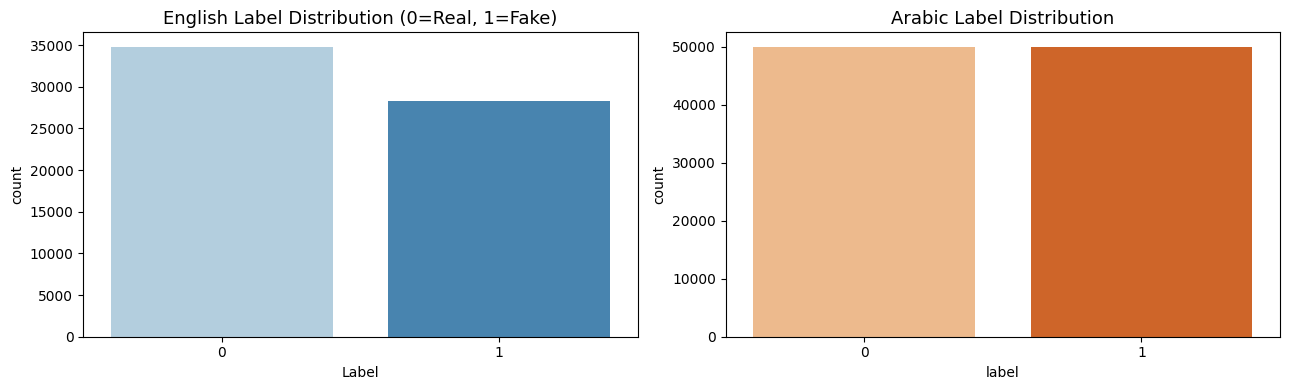

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(x='label', data=df_en, ax=axes[0], palette='Blues')
axes[0].set_title('English Label Distribution (0=Real, 1=Fake)', fontsize=13)
axes[0].set_xlabel('Label')
sns.countplot(x='label', data=df_ar, ax=axes[1], palette='Oranges')
axes[1].set_title('Arabic Label Distribution', fontsize=13)
plt.tight_layout()
plt.show()

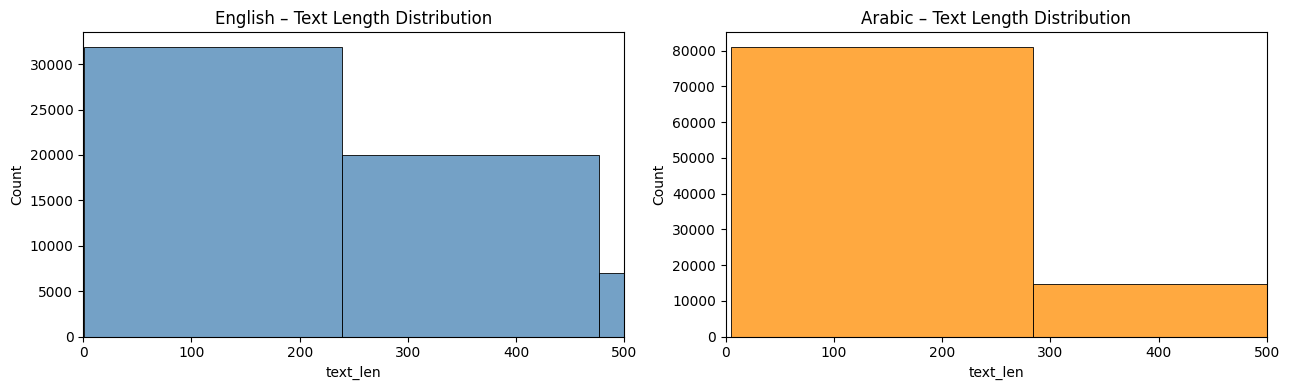

In [9]:
# Text length distribution
df_en['text_len'] = df_en['clean_text'].str.split().str.len()
df_ar['text_len'] = df_ar['clean_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_en['text_len'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('English – Text Length Distribution')
axes[0].set_xlim(0, 500)
sns.histplot(df_ar['text_len'], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Arabic – Text Length Distribution')
axes[1].set_xlim(0, 500)
plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [10]:
X_en, y_en = df_en['clean_text'], df_en['label'].astype(int)
X_en_train, X_en_test, y_en_train, y_en_test = train_test_split(
    X_en, y_en, test_size=0.2, random_state=42, stratify=y_en)
print(f'English → Train: {len(X_en_train):,} | Test: {len(X_en_test):,}')

X_ar, y_ar = df_ar['clean_text'], df_ar['label'].astype(int)
X_ar_train, X_ar_test, y_ar_train, y_ar_test = train_test_split(
    X_ar, y_ar, test_size=0.2, random_state=42, stratify=y_ar)
print(f'Arabic  → Train: {len(X_ar_train):,} | Test: {len(X_ar_test):,}')

English → Train: 50,456 | Test: 12,614
Arabic  → Train: 80,000 | Test: 20,000


## 6. TF-IDF

In [11]:
tfidf_en = TfidfVectorizer(max_features=20000, ngram_range=(1, 3), min_df=2, max_df=0.9, sublinear_tf=True)
X_en_train_tfidf = tfidf_en.fit_transform(X_en_train)
X_en_test_tfidf  = tfidf_en.transform(X_en_test)

tfidf_ar = TfidfVectorizer(max_features=25000, ngram_range=(1, 2), min_df=3, max_df=0.85)
X_ar_train_tfidf = tfidf_ar.fit_transform(X_ar_train)
X_ar_test_tfidf  = tfidf_ar.transform(X_ar_test)

print('EN TF-IDF:', X_en_train_tfidf.shape)
print('AR TF-IDF:', X_ar_train_tfidf.shape)

EN TF-IDF: (50456, 20000)
AR TF-IDF: (80000, 25000)


## 7. Full Evaluation Helper

In [12]:
results = []

def evaluate_model(y_true, y_pred, y_prob, model_name, labels=['Real', 'Fake']):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f'\n{"="*55}')
    print(f'{model_name}')
    print(f'{"="*55}')
    print(f'Accuracy : {acc:.4f}  |  Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}  |  F1-Score : {f1:.4f}  |  Macro-F1: {macro:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'{model_name}\nConfusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    results.append({'Model': model_name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1-Score': f1, 'Macro-F1': macro})
    return acc, f1, y_prob

## 8. Classical Models 

Training EN Logistic Regression...

EN – Logistic Regression
Accuracy : 0.9616  |  Precision: 0.9519
Recall   : 0.9629  |  F1-Score : 0.9574  |  Macro-F1: 0.9612

Classification Report:
              precision    recall  f1-score   support

        Real     0.9695    0.9605    0.9650      6958
        Fake     0.9519    0.9629    0.9574      5656

    accuracy                         0.9616     12614
   macro avg     0.9607    0.9617    0.9612     12614
weighted avg     0.9616    0.9616    0.9616     12614



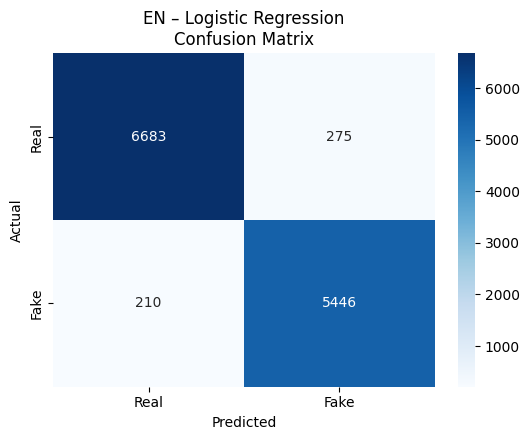

(0.9615506579990487,
 0.9573701327239167,
 array([0.92776262, 0.99699465, 0.95098378, ..., 0.41349085, 0.97371308,
        0.55783643]))

In [13]:
print('Training EN Logistic Regression...')
lr_en = LogisticRegression(max_iter=2000, class_weight='balanced', C=2.0, solver='saga', random_state=42, n_jobs=-1)
lr_en.fit(X_en_train_tfidf, y_en_train)
pred = lr_en.predict(X_en_test_tfidf)
prob = lr_en.predict_proba(X_en_test_tfidf)[:, 1]
evaluate_model(y_en_test, pred, prob, 'EN – Logistic Regression')

Training EN XGBoost (optimized)...

EN – XGBoost
Accuracy : 0.9578  |  Precision: 0.9411
Recall   : 0.9664  |  F1-Score : 0.9536  |  Macro-F1: 0.9575

Classification Report:
              precision    recall  f1-score   support

        Real     0.9721    0.9508    0.9613      6958
        Fake     0.9411    0.9664    0.9536      5656

    accuracy                         0.9578     12614
   macro avg     0.9566    0.9586    0.9575     12614
weighted avg     0.9582    0.9578    0.9579     12614



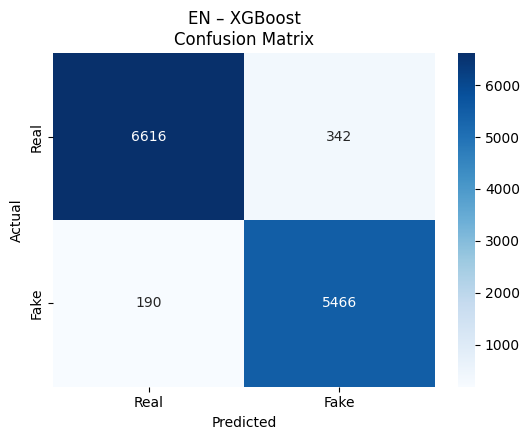

(0.9578246392896781,
 0.9535938590369855,
 array([0.9547038 , 0.9984486 , 0.99381316, ..., 0.33350286, 0.97584945,
        0.0463573 ], dtype=float32))

In [14]:
print('Training EN XGBoost (optimized)...')
xgb_en = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.04,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.3, reg_lambda=1.0,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_en.fit(X_en_train_tfidf, y_en_train)
pred = xgb_en.predict(X_en_test_tfidf)
prob = xgb_en.predict_proba(X_en_test_tfidf)[:, 1]
evaluate_model(y_en_test, pred, prob, 'EN – XGBoost')

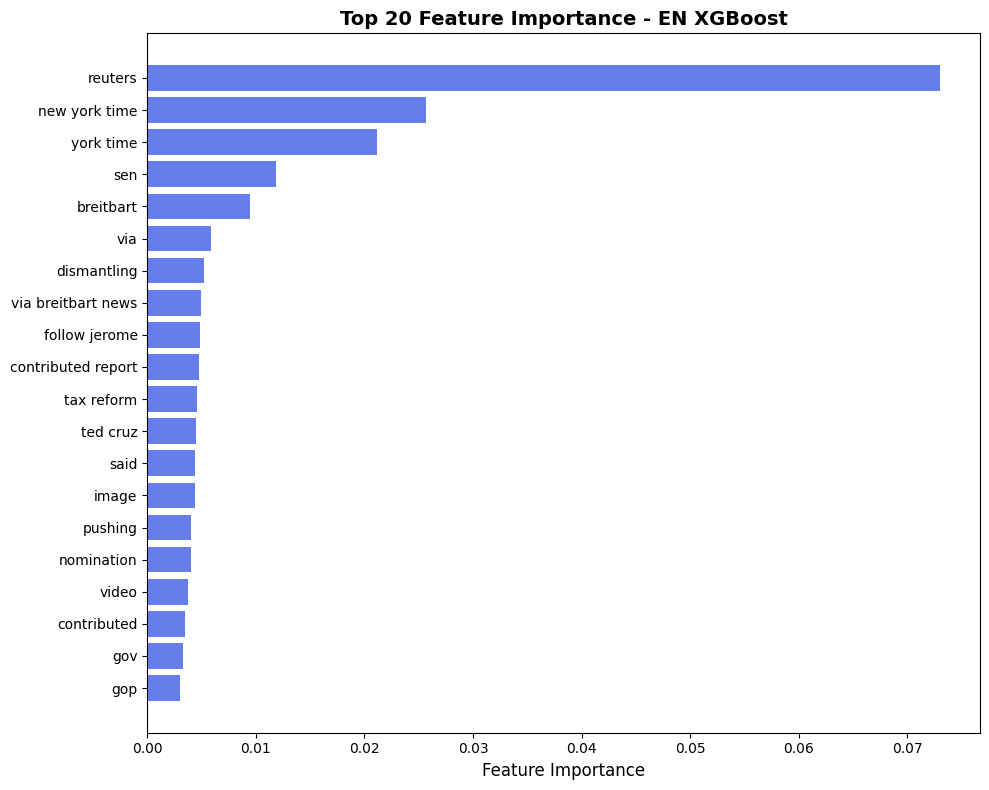

In [15]:
# Feature Importance (Top 20) - English XGBoost
importance_xgb = xgb_en.feature_importances_
feature_names = tfidf_en.get_feature_names_out()
indices = np.argsort(importance_xgb)[-20:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importance_xgb[indices], color='#667eea')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 20 Feature Importance - EN XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

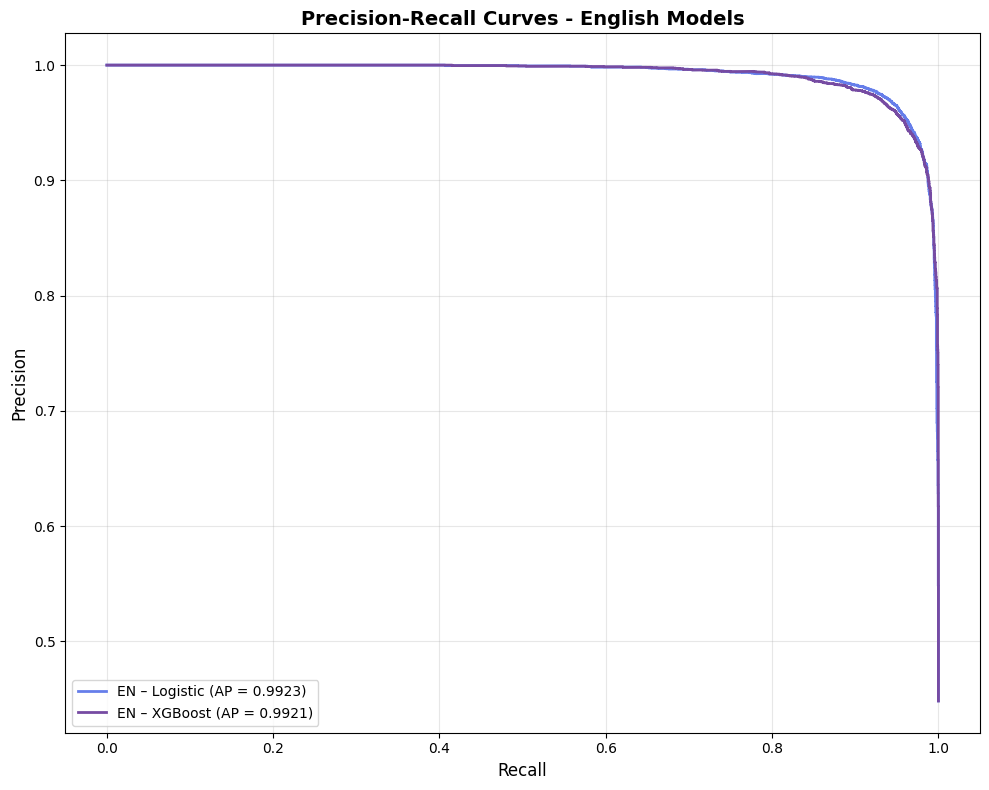

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))

model_probs = {
    'EN – Logistic': lr_en.predict_proba(X_en_test_tfidf)[:, 1],
    'EN – XGBoost': xgb_en.predict_proba(X_en_test_tfidf)[:, 1],
}

colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe']

for (name, probs), color in zip(model_probs.items(), colors):
    precision, recall, _ = precision_recall_curve(y_en_test, probs)
    ap = average_precision_score(y_en_test, probs)
    plt.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - English Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

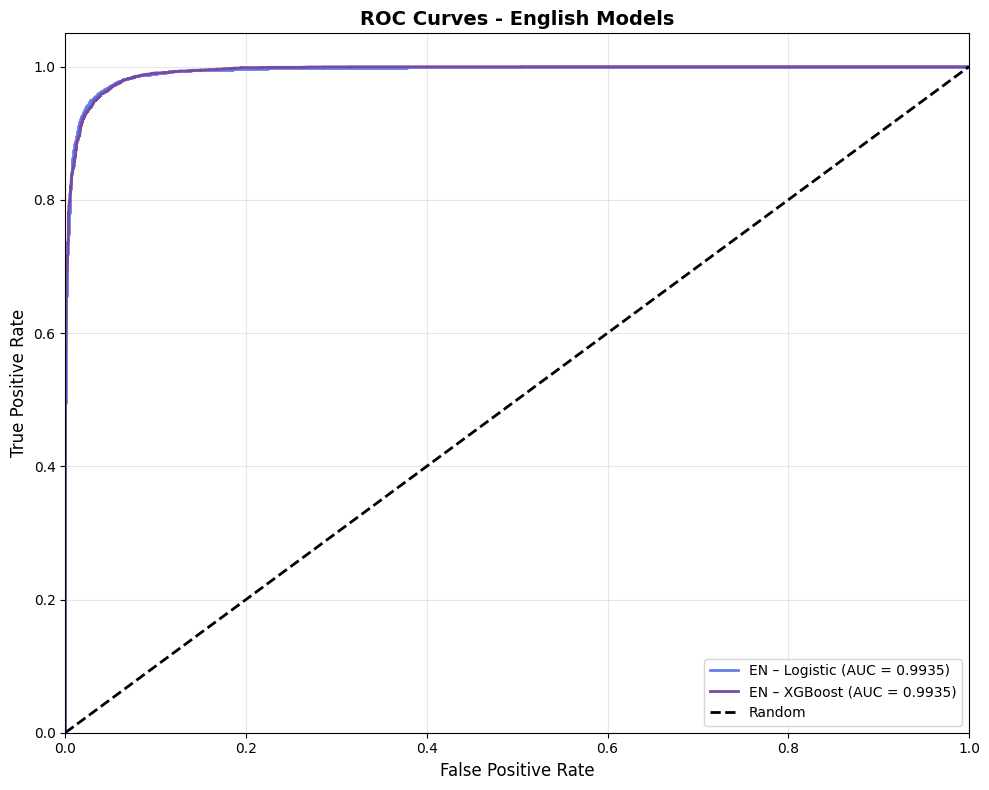

In [17]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

model_probs = {
    'EN – Logistic': lr_en.predict_proba(X_en_test_tfidf)[:, 1],
    'EN – XGBoost': xgb_en.predict_proba(X_en_test_tfidf)[:, 1],
}

colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe', '#00f2fe', '#f5576c']

for (name, probs), color in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_en_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - English Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training AR Logistic Regression...

AR – Logistic Regression
Accuracy : 0.7806  |  Precision: 0.7796
Recall   : 0.7824  |  F1-Score : 0.7810  |  Macro-F1: 0.7806

Classification Report:
              precision    recall  f1-score   support

        Real     0.7816    0.7788    0.7802     10000
        Fake     0.7796    0.7824    0.7810     10000

    accuracy                         0.7806     20000
   macro avg     0.7806    0.7806    0.7806     20000
weighted avg     0.7806    0.7806    0.7806     20000



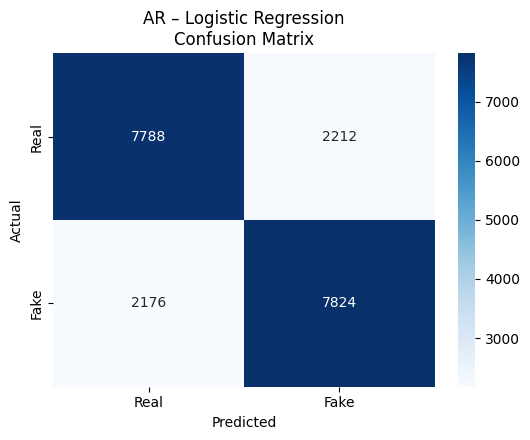

(0.7806,
 0.7809942104212418,
 array([0.7045121 , 0.50012375, 0.64099394, ..., 0.62196865, 0.3276303 ,
        0.41733878]))

In [18]:
print('Training AR Logistic Regression...')
lr_ar = LogisticRegression(max_iter=2000, class_weight='balanced', C=2.0, solver='saga', random_state=42, n_jobs=-1)
lr_ar.fit(X_ar_train_tfidf, y_ar_train)
pred = lr_ar.predict(X_ar_test_tfidf)
prob = lr_ar.predict_proba(X_ar_test_tfidf)[:, 1]
evaluate_model(y_ar_test, pred, prob, 'AR – Logistic Regression')

Training AR Random Forest (optimized)...

AR – Random Forest
Accuracy : 0.8090  |  Precision: 0.7948
Recall   : 0.8330  |  F1-Score : 0.8135  |  Macro-F1: 0.8089

Classification Report:
              precision    recall  f1-score   support

        Real     0.8246    0.7850    0.8043     10000
        Fake     0.7948    0.8330    0.8135     10000

    accuracy                         0.8090     20000
   macro avg     0.8097    0.8090    0.8089     20000
weighted avg     0.8097    0.8090    0.8089     20000



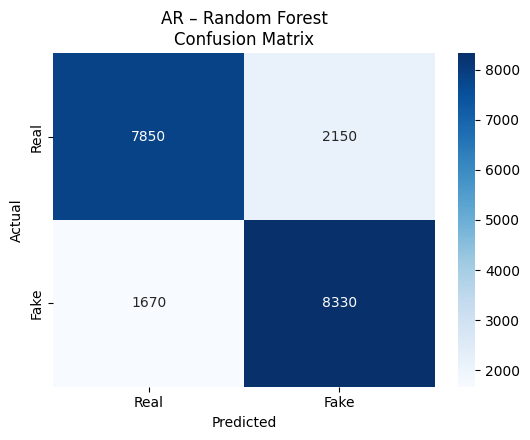

(0.809,
 0.8134765625,
 array([0.65096454, 0.53419624, 0.56306942, ..., 0.67666948, 0.14389246,
        0.27700235]))

In [19]:
print('Training AR Random Forest (optimized)...')
rf_ar = RandomForestClassifier(
    n_estimators=250, max_depth=None, min_samples_split=4,
    min_samples_leaf=2, class_weight='balanced_subsample',
    random_state=42, n_jobs=-1
)
rf_ar.fit(X_ar_train_tfidf, y_ar_train)
pred = rf_ar.predict(X_ar_test_tfidf)
prob = rf_ar.predict_proba(X_ar_test_tfidf)[:, 1]
evaluate_model(y_ar_test, pred, prob, 'AR – Random Forest')

## 9. Sequence Models 

In [20]:
MAX_WORDS = 25000
MAX_LEN = 250

def prepare_sequences(train_texts, test_texts):
    tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tok.fit_on_texts(train_texts)
    tr = pad_sequences(tok.texts_to_sequences(train_texts), maxlen=MAX_LEN, padding='post', truncating='post')
    te = pad_sequences(tok.texts_to_sequences(test_texts),  maxlen=MAX_LEN, padding='post', truncating='post')
    return tok, tr, te

tok_en, X_en_train_pad, X_en_test_pad = prepare_sequences(X_en_train, X_en_test)
tok_ar, X_ar_train_pad, X_ar_test_pad = prepare_sequences(X_ar_train, X_ar_test)
print('EN seq:', X_en_train_pad.shape, '| AR seq:', X_ar_train_pad.shape)

EN seq: (50456, 250) | AR seq: (80000, 250)


In [21]:
def build_bilstm():
    model = Sequential([
        Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.25),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(8e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_lstm():
    model = Sequential([
        Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
        SpatialDropout1D(0.2),
        Conv1D(128, 5, activation='relu', padding='same'),
        MaxPooling1D(2),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(8e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

Training EN BiLSTM on full data...
Epoch 1/8


I0000 00:00:1790189808.812779      91 cuda_dnn.cc:529] Loaded cuDNN version 90300


710/710 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.8848 - loss: 0.2489 - val_accuracy: 0.9457 - val_loss: 0.1358 - learning_rate: 8.0000e-04
Epoch 2/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.9781 - loss: 0.0634 - val_accuracy: 0.9627 - val_loss: 0.1119 - learning_rate: 8.0000e-04
Epoch 3/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9944 - loss: 0.0181 - val_accuracy: 0.9554 - val_loss: 0.1492 - learning_rate: 8.0000e-04
Epoch 4/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.9977 - loss: 0.0082 - val_accuracy: 0.9536 - val_loss: 0.2078 - learning_rate: 8.0000e-04
Epoch 5/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9986 - loss: 0.0047 - val_accuracy: 0.9625 - val_loss: 0.2274 - learning_rate: 4.0000e-04

EN – BiLSTM
Accuracy : 0.9619  |  Precision: 0.9398
Recall   : 0.9777  |  F1-Score : 0.9584  |  Macro-F1: 0.9617

Classification Report:
              precision    recall  f1-score   support

        Real     0.9813    0.949

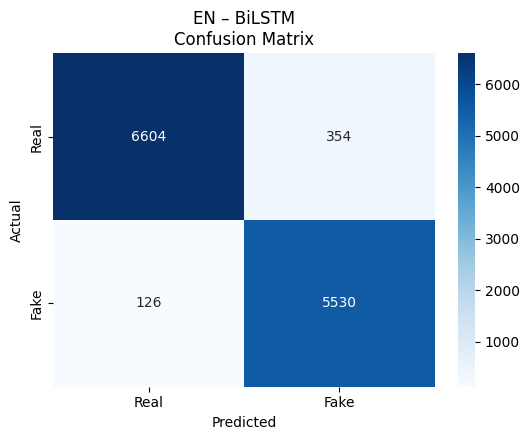

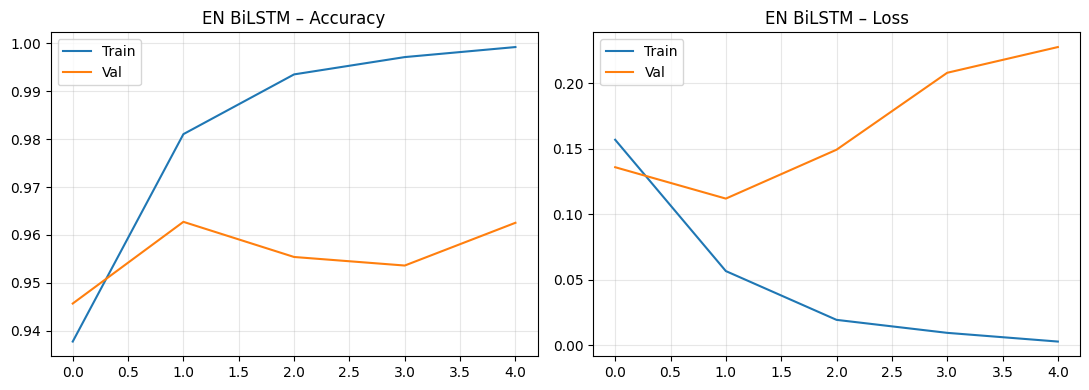

In [22]:
print('Training EN BiLSTM on full data...')
bilstm_en = build_bilstm()
hist_en_bi = bilstm_en.fit(X_en_train_pad, y_en_train, validation_split=0.1,
                           epochs=8, batch_size=64, callbacks=callbacks, verbose=1)
pred = (bilstm_en.predict(X_en_test_pad, verbose=0) > 0.5).astype(int).flatten()
prob = bilstm_en.predict(X_en_test_pad, verbose=0).flatten()
evaluate_model(y_en_test, pred, prob, 'EN – BiLSTM')

# Learning curve
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_en_bi.history['accuracy'], label='Train')
plt.plot(hist_en_bi.history['val_accuracy'], label='Val')
plt.title('EN BiLSTM – Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(hist_en_bi.history['loss'], label='Train')
plt.plot(hist_en_bi.history['val_loss'], label='Val')
plt.title('EN BiLSTM – Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gc.collect(); tf.keras.backend.clear_session()

Training EN CNN-LSTM on full data...
Epoch 1/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.7251 - loss: 0.5354 - val_accuracy: 0.9075 - val_loss: 0.2975 - learning_rate: 8.0000e-04
Epoch 2/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9165 - loss: 0.2595 - val_accuracy: 0.9316 - val_loss: 0.1858 - learning_rate: 8.0000e-04
Epoch 3/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9426 - loss: 0.1697 - val_accuracy: 0.9520 - val_loss: 0.1350 - learning_rate: 8.0000e-04
Epoch 4/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9707 - loss: 0.0907 - val_accuracy: 0.9528 - val_loss: 0.1375 - learning_rate: 8.0000e-04
Epoch 5/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9844 - loss: 0.0528 - val_accuracy: 0.9511 - val_loss: 0.1478 - learning_rate: 8.0000e-04
Epoch 6/8
710/710 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9908 - loss: 0.0324 - val_accuracy: 0.9536 - val_loss: 0.1507 - learning_rate: 4.0000e-04

EN – CNN-LSTM
Accura

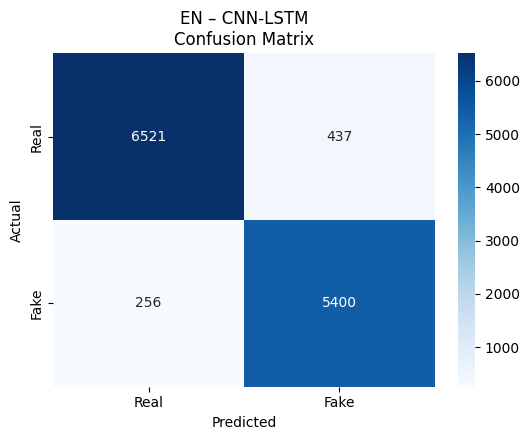

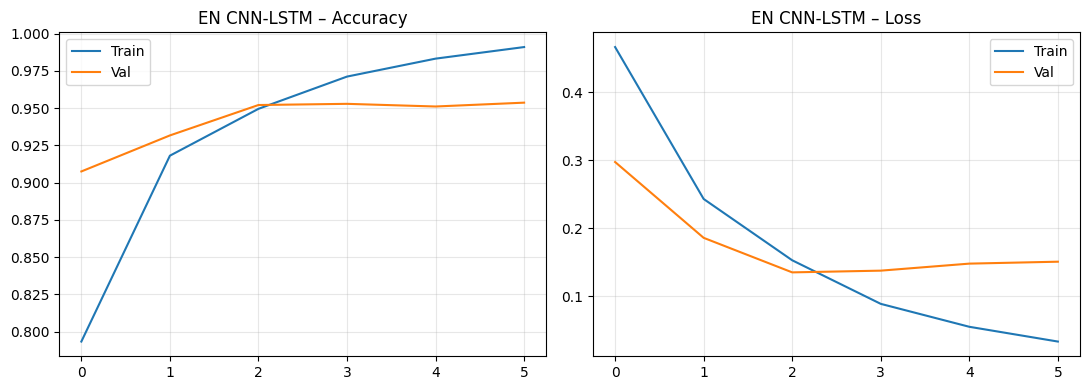

In [23]:
print('Training EN CNN-LSTM on full data...')
cnn_en = build_cnn_lstm()
hist_en_cnn = cnn_en.fit(X_en_train_pad, y_en_train, validation_split=0.1,
                         epochs=8, batch_size=64, callbacks=callbacks, verbose=1)
pred = (cnn_en.predict(X_en_test_pad, verbose=0) > 0.5).astype(int).flatten()
prob = cnn_en.predict(X_en_test_pad, verbose=0).flatten()
evaluate_model(y_en_test, pred, prob, 'EN – CNN-LSTM')

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_en_cnn.history['accuracy'], label='Train')
plt.plot(hist_en_cnn.history['val_accuracy'], label='Val')
plt.title('EN CNN-LSTM – Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(hist_en_cnn.history['loss'], label='Train')
plt.plot(hist_en_cnn.history['val_loss'], label='Val')
plt.title('EN CNN-LSTM – Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gc.collect(); tf.keras.backend.clear_session()

Training AR BiLSTM on full data...
Epoch 1/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.6887 - loss: 0.5361 - val_accuracy: 0.7821 - val_loss: 0.4034 - learning_rate: 8.0000e-04
Epoch 2/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.8379 - loss: 0.3323 - val_accuracy: 0.7977 - val_loss: 0.4017 - learning_rate: 8.0000e-04
Epoch 3/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.8956 - loss: 0.2347 - val_accuracy: 0.7901 - val_loss: 0.4596 - learning_rate: 8.0000e-04
Epoch 4/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.9197 - loss: 0.1848 - val_accuracy: 0.7887 - val_loss: 0.5349 - learning_rate: 8.0000e-04
Epoch 5/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.9605 - loss: 0.1000 - val_accuracy: 0.7899 - val_loss: 0.7426 - learning_rate: 4.0000e-04

AR – BiLSTM
Accuracy : 0.7906  |  Precision: 0.7622
Recall   : 0.8447  |  F1-Score : 0.8013  |  Macro-F1: 0.7900

Classification Report:
              precision    recal

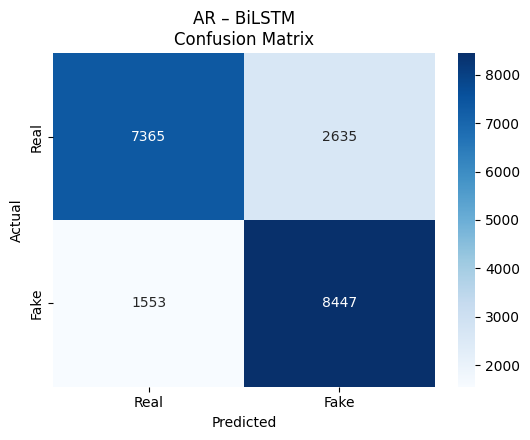

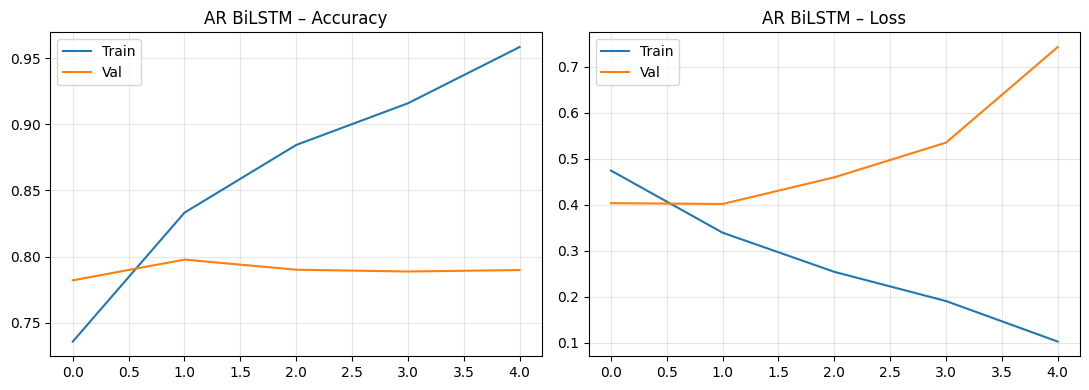

In [24]:
print('Training AR BiLSTM on full data...')
bilstm_ar = build_bilstm()
hist_ar_bi = bilstm_ar.fit(X_ar_train_pad, y_ar_train, validation_split=0.1,
                           epochs=8, batch_size=64, callbacks=callbacks, verbose=1)
pred = (bilstm_ar.predict(X_ar_test_pad, verbose=0) > 0.5).astype(int).flatten()
prob = bilstm_ar.predict(X_ar_test_pad, verbose=0).flatten()
evaluate_model(y_ar_test, pred, prob, 'AR – BiLSTM')

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_ar_bi.history['accuracy'], label='Train')
plt.plot(hist_ar_bi.history['val_accuracy'], label='Val')
plt.title('AR BiLSTM – Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(hist_ar_bi.history['loss'], label='Train')
plt.plot(hist_ar_bi.history['val_loss'], label='Val')
plt.title('AR BiLSTM – Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gc.collect(); tf.keras.backend.clear_session()

Training AR CNN-LSTM on full data...
Epoch 1/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.5030 - loss: 0.6930 - val_accuracy: 0.5239 - val_loss: 0.6883 - learning_rate: 8.0000e-04
Epoch 2/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.5468 - loss: 0.6827 - val_accuracy: 0.6085 - val_loss: 0.6954 - learning_rate: 8.0000e-04
Epoch 3/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.6319 - loss: 0.6342 - val_accuracy: 0.7001 - val_loss: 0.5531 - learning_rate: 8.0000e-04
Epoch 4/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.7637 - loss: 0.4791 - val_accuracy: 0.7460 - val_loss: 0.4602 - learning_rate: 8.0000e-04
Epoch 5/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8289 - loss: 0.3516 - val_accuracy: 0.7700 - val_loss: 0.4391 - learning_rate: 8.0000e-04
Epoch 6/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8824 - loss: 0.2600 - val_accuracy: 0.7725 - val_loss: 0.4793 - learning_rate: 8.0000e-04
Epoch 7/8

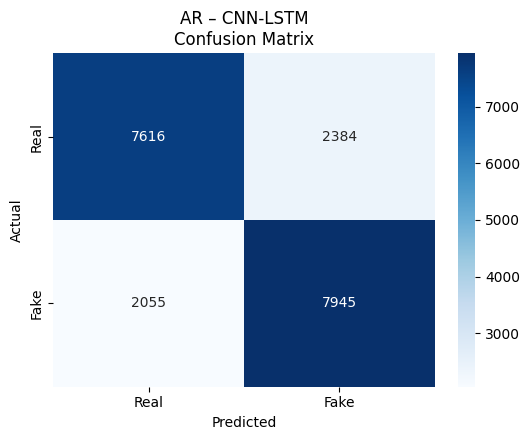

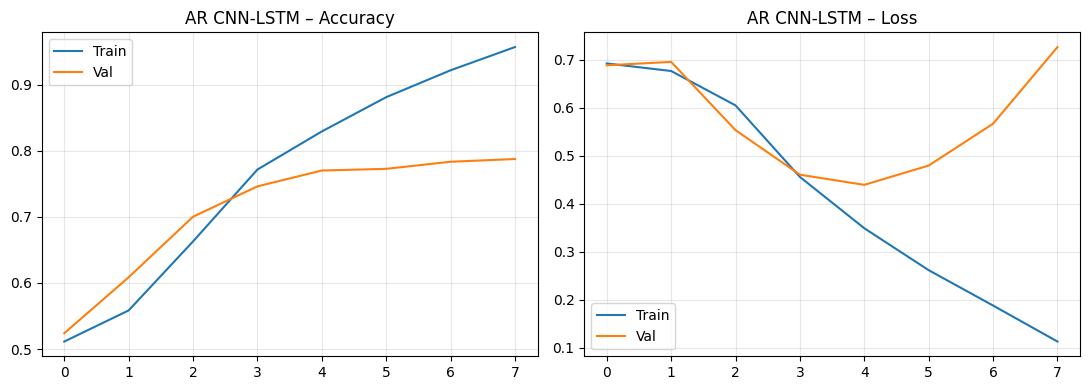

In [25]:
print('Training AR CNN-LSTM on full data...')
cnn_ar = build_cnn_lstm()
hist_ar_cnn = cnn_ar.fit(X_ar_train_pad, y_ar_train, validation_split=0.1,
                         epochs=8, batch_size=64, callbacks=callbacks, verbose=1)
pred = (cnn_ar.predict(X_ar_test_pad, verbose=0) > 0.5).astype(int).flatten()
prob = cnn_ar.predict(X_ar_test_pad, verbose=0).flatten()
evaluate_model(y_ar_test, pred, prob, 'AR – CNN-LSTM')

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_ar_cnn.history['accuracy'], label='Train')
plt.plot(hist_ar_cnn.history['val_accuracy'], label='Val')
plt.title('AR CNN-LSTM – Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(hist_ar_cnn.history['loss'], label='Train')
plt.plot(hist_ar_cnn.history['val_loss'], label='Val')
plt.title('AR CNN-LSTM – Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gc.collect(); tf.keras.backend.clear_session()

## 10. Transformers 

In [26]:
def train_transformer(model_name, train_texts, train_labels, test_texts, test_labels,
                      max_len=128, epochs=3, batch_size=16):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_enc = tokenizer(list(train_texts), truncation=True, padding=True,
                          max_length=max_len, return_tensors='tf')
    test_enc  = tokenizer(list(test_texts), truncation=True, padding=True,
                          max_length=max_len, return_tensors='tf')
    
    model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    optimizer = AdamWeightDecay(learning_rate=2e-5, weight_decay_rate=0.01)
    model.compile(optimizer=optimizer,
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    history = model.fit(train_enc.data, np.array(train_labels),
                        validation_split=0.1, epochs=epochs,
                        batch_size=batch_size, verbose=1)
    
    logits = model.predict(test_enc.data, verbose=0).logits
    preds = np.argmax(logits, axis=1)
    probs = tf.nn.softmax(logits).numpy()[:, 1]
    return preds, probs, history, model, tokenizer

Training EN DistilBERT on FULL data (this will take time)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
2839/2839 [==============================] - 740s 256ms/step - loss: 0.1109 - accuracy: 0.9559 - val_loss: 0.0689 - val_accuracy: 0.9715
Epoch 2/3
2839/2839 [==============================] - 723s 255ms/step - loss: 0.0413 - accuracy: 0.9850 - val_loss: 0.0747 - val_accuracy: 0.9728
Epoch 3/3
2839/2839 [==============================] - 724s 255ms/step - loss: 0.0204 - accuracy: 0.9926 - val_loss: 0.0753 - val_accuracy: 0.9748

EN – DistilBERT
Accuracy : 0.9772  |  Precision: 0.9689
Recall   : 0.9807  |  F1-Score : 0.9748  |  Macro-F1: 0.9770

Classification Report:
              precision    recall  f1-score   support

        Real     0.9842    0.9744    0.9793      6958
        Fake     0.9689    0.9807    0.9748      5656

    accuracy                         0.9772     12614
   macro avg     0.9765    0.9776    0.9770     12614
weighted avg     0.9773    0.9772    0.9773     12614



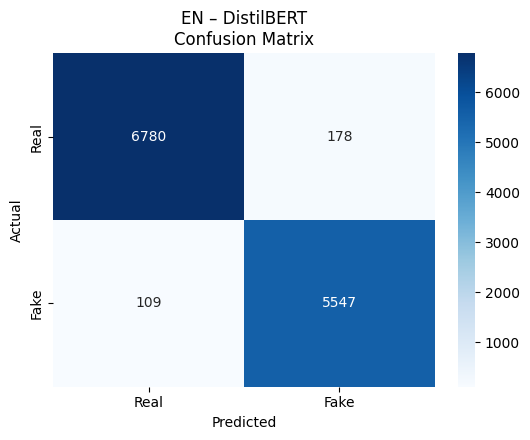

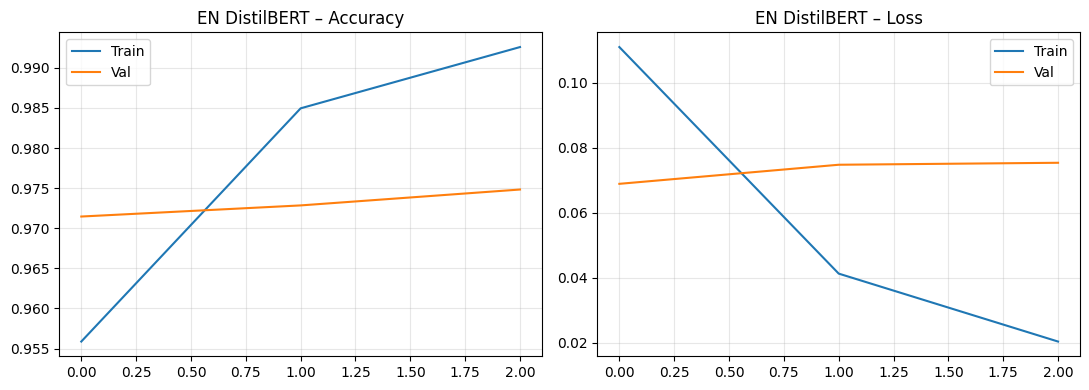

In [27]:
if TRANSFORMERS_AVAILABLE:
    print('Training EN DistilBERT on FULL data (this will take time)...')
    pred, prob, hist_db, model_db, tok_db = train_transformer(
        'distilbert-base-uncased',
        X_en_train, y_en_train,
        X_en_test, y_en_test,
        max_len=128, epochs=3, batch_size=16
    )
    evaluate_model(y_en_test, pred, prob, 'EN – DistilBERT')
    
    plt.figure(figsize=(11, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist_db.history['accuracy'], label='Train')
    plt.plot(hist_db.history['val_accuracy'], label='Val')
    plt.title('EN DistilBERT – Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(hist_db.history['loss'], label='Train')
    plt.plot(hist_db.history['val_loss'], label='Val')
    plt.title('EN DistilBERT – Loss'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    
    gc.collect(); tf.keras.backend.clear_session()
else:
    print('Transformers not available')

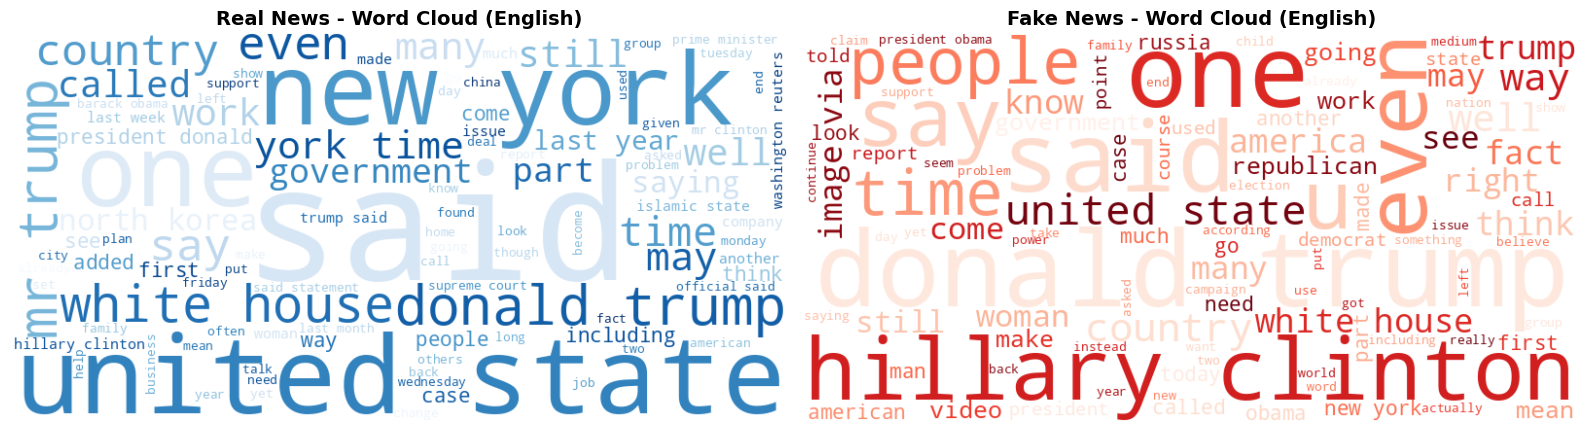

In [28]:
from wordcloud import WordCloud
real_text = ' '.join(df_en[df_en['label'] == 0]['clean_text'].values)
wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Blues', max_words=100).generate(real_text)
fake_text = ' '.join(df_en[df_en['label'] == 1]['clean_text'].values)
wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].set_title('Real News - Word Cloud (English)', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Fake News - Word Cloud (English)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Training AR AraBERTv2 on FULL data (this will take time)...


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
9000/9000 [==============================] - 2635s 291ms/step - loss: 0.6971 - accuracy: 0.5065 - val_loss: 0.6930 - val_accuracy: 0.5080
Epoch 2/3
9000/9000 [==============================] - 2615s 291ms/step - loss: 0.6992 - accuracy: 0.5006 - val_loss: 0.6930 - val_accuracy: 0.5080
Epoch 3/3
9000/9000 [==============================] - 2615s 291ms/step - loss: 0.6980 - accuracy: 0.4981 - val_loss: 0.6933 - val_accuracy: 0.4920

AR – AraBERTv2
Accuracy : 0.5000  |  Precision: 0.0000
Recall   : 0.0000  |  F1-Score : 0.0000  |  Macro-F1: 0.3333

Classification Report:
              precision    recall  f1-score   support

        Real     0.5000    1.0000    0.6667     10000
        Fake     0.0000    0.0000    0.0000     10000

    accuracy                         0.5000     20000
   macro avg     0.2500    0.5000    0.3333     20000
weighted avg     0.2500    0.5000    0.3333     20000



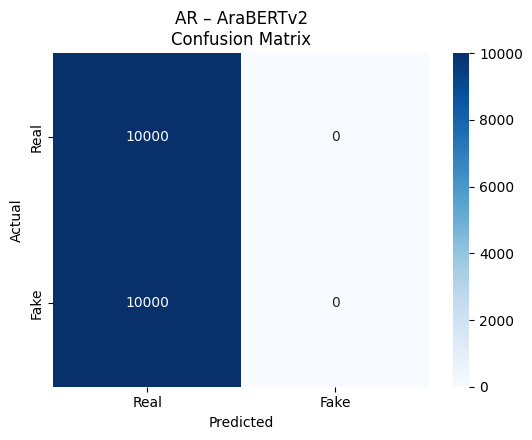

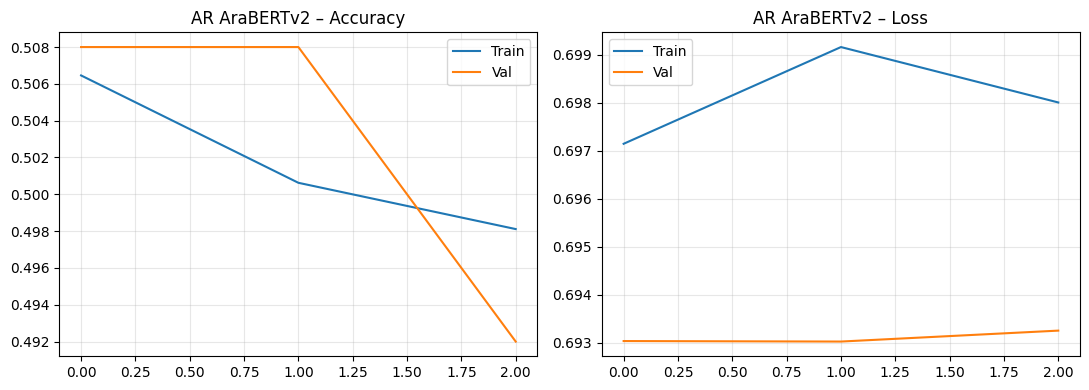

In [29]:
if TRANSFORMERS_AVAILABLE:
    print('Training AR AraBERTv2 on FULL data (this will take time)...')
    pred, prob, hist_ara, model_ara, tok_ara = train_transformer(
        'aubmindlab/bert-base-arabertv2',
        X_ar_train, y_ar_train,
        X_ar_test, y_ar_test,
        max_len=128, epochs=3, batch_size=8
    )
    evaluate_model(y_ar_test, pred, prob, 'AR – AraBERTv2')
    
    plt.figure(figsize=(11, 4))
    plt.subplot(1, 2, 1)
    plt.plot(hist_ara.history['accuracy'], label='Train')
    plt.plot(hist_ara.history['val_accuracy'], label='Val')
    plt.title('AR AraBERTv2 – Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(hist_ara.history['loss'], label='Train')
    plt.plot(hist_ara.history['val_loss'], label='Val')
    plt.title('AR AraBERTv2 – Loss'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    
    gc.collect(); tf.keras.backend.clear_session()

## 11. Final Leaderboard + Comparison Charts


FINAL LEADERBOARD (Full Data Training)
                   Model  Accuracy  Precision   Recall  F1-Score  Macro-F1
         EN – DistilBERT  0.977248   0.968908 0.980728  0.974783  0.977028
             EN – BiLSTM  0.961947   0.939837 0.977723  0.958406  0.961669
EN – Logistic Regression  0.961551   0.951931 0.962871  0.957370  0.961177
            EN – XGBoost  0.957825   0.941116 0.966407  0.953594  0.957471
           EN – CNN-LSTM  0.945061   0.925133 0.954738  0.939702  0.944624
      AR – Random Forest  0.809000   0.794847 0.833000  0.813477  0.808890
             AR – BiLSTM  0.790600   0.762227 0.844700  0.801347  0.789985
           AR – CNN-LSTM  0.778050   0.769194 0.794500  0.781642  0.777990
AR – Logistic Regression  0.780600   0.779593 0.782400  0.780994  0.780599
          AR – AraBERTv2  0.500000   0.000000 0.000000  0.000000  0.333333


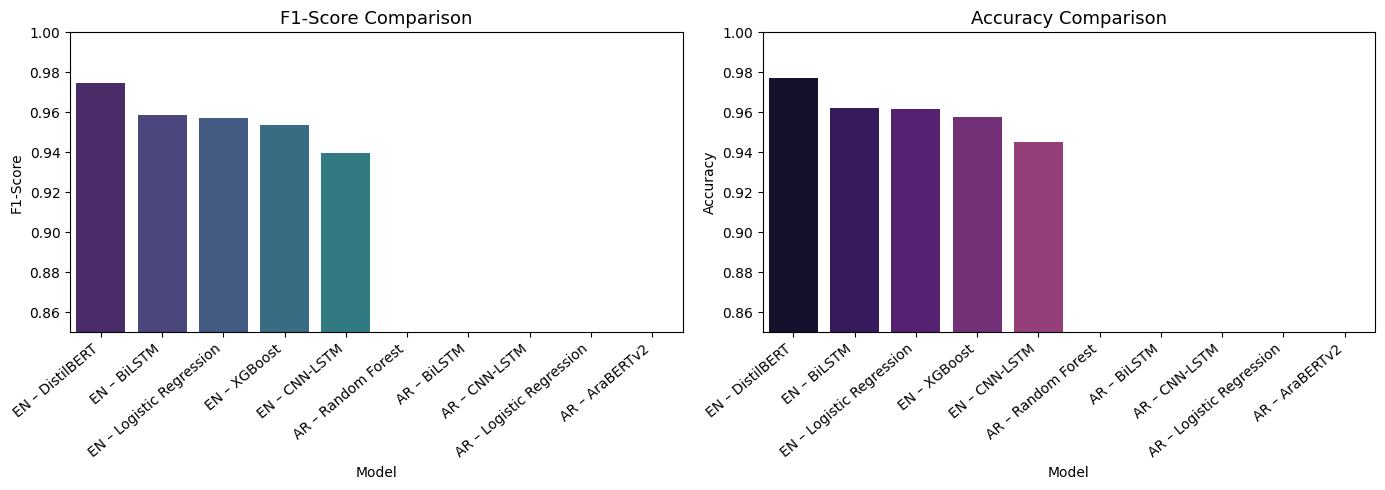

In [30]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\n' + '='*70)
print('FINAL LEADERBOARD (Full Data Training)')
print('='*70)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x='Model', y='F1-Score', ax=axes[0], palette='viridis')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')
axes[0].set_title('F1-Score Comparison', fontsize=13)
axes[0].set_ylim(0.85, 1.0)

sns.barplot(data=results_df, x='Model', y='Accuracy', ax=axes[1], palette='magma')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right')
axes[1].set_title('Accuracy Comparison', fontsize=13)
axes[1].set_ylim(0.85, 1.0)
plt.tight_layout()
plt.show()

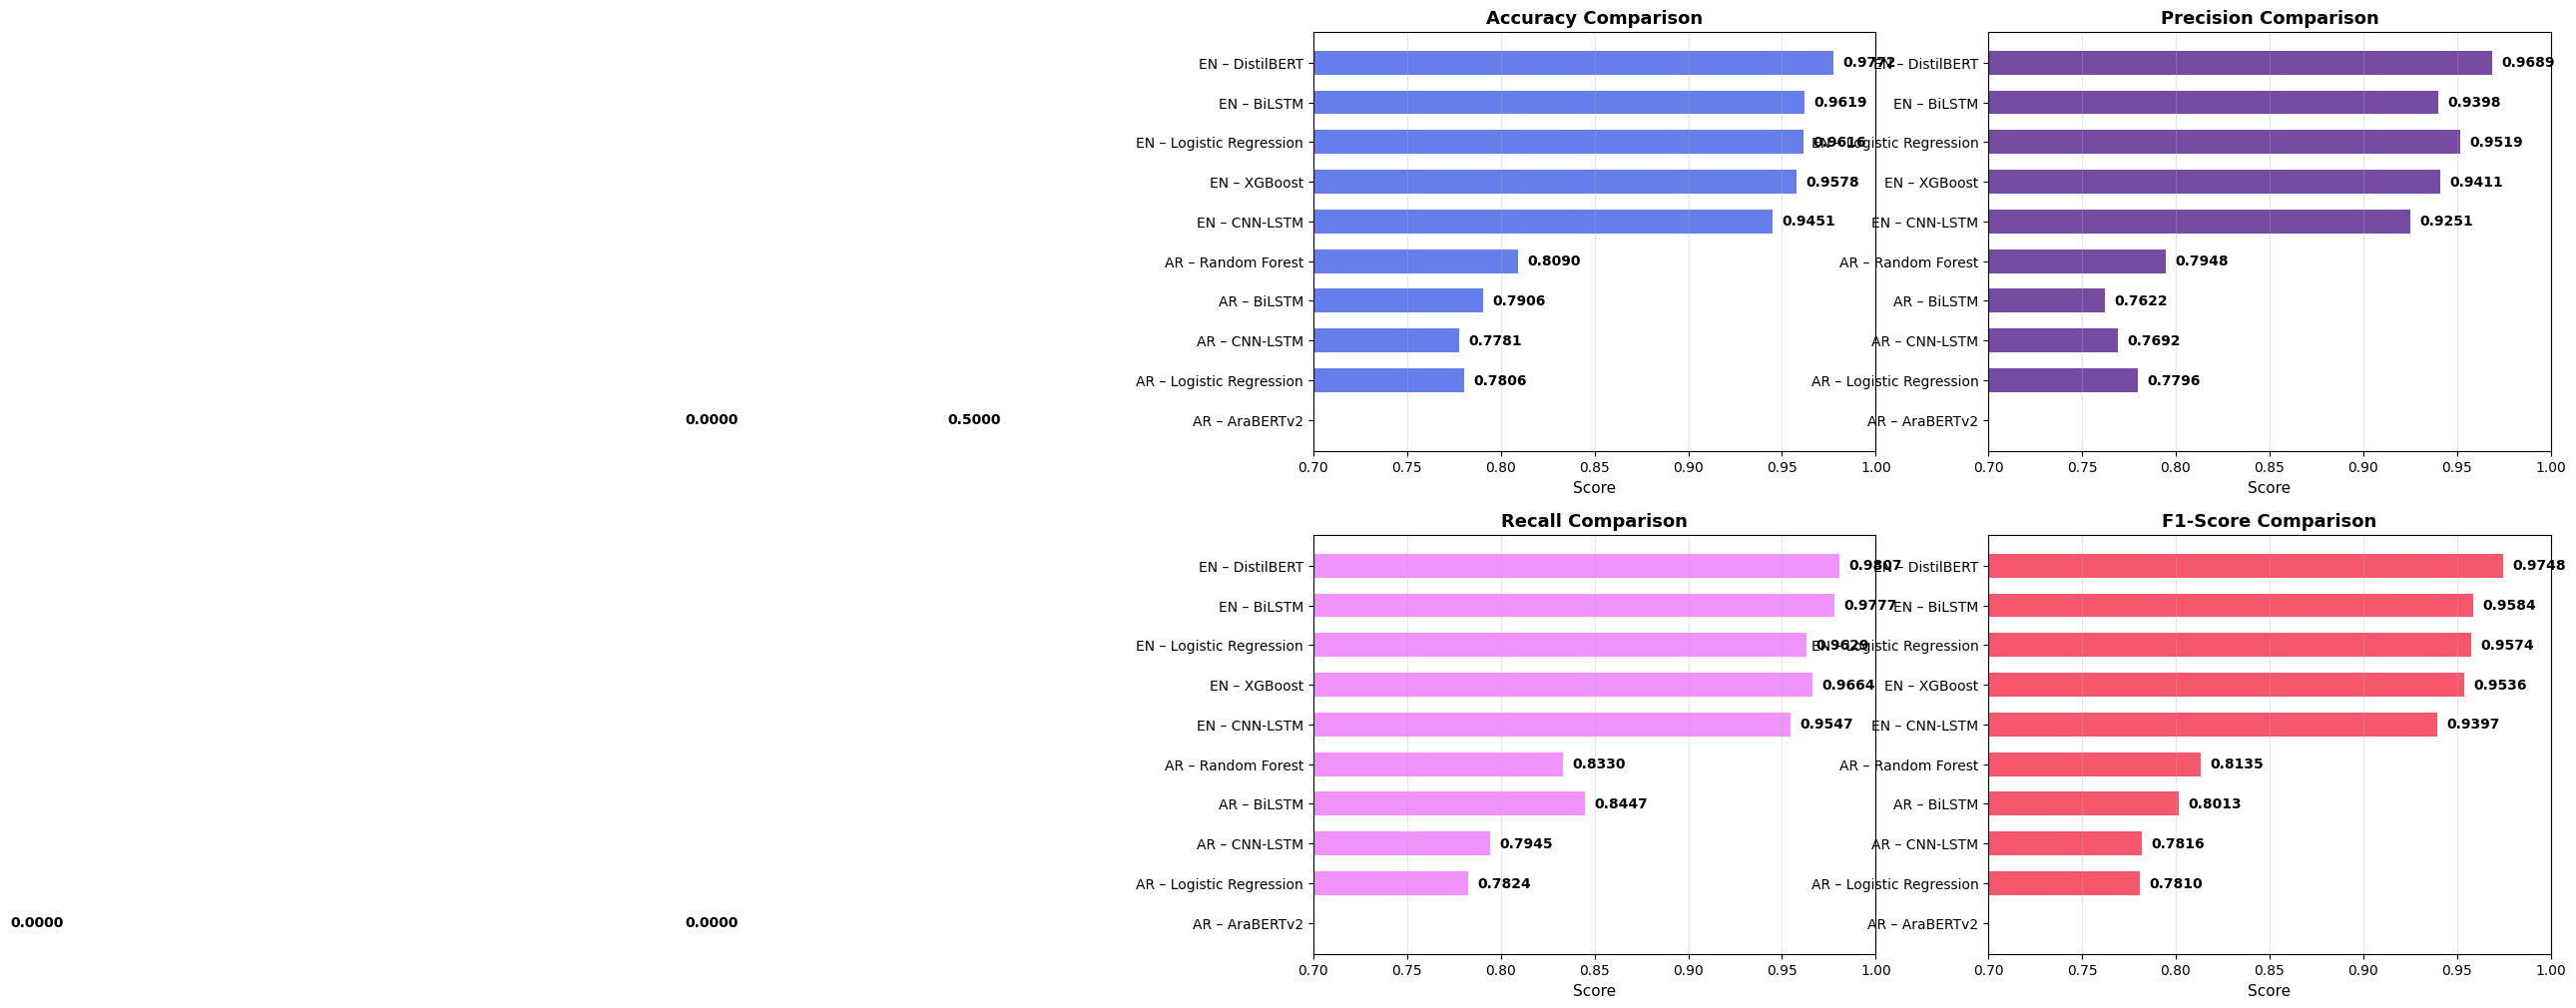

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#667eea', '#764ba2', '#f093fb', '#f5576c']

results_sorted = results_df.sort_values('F1-Score', ascending=True)

for ax, metric, color in zip(axes.flat, metrics, colors):
    values = results_sorted[metric].values
    models = results_sorted['Model'].values
    
    bars = ax.barh(models, values, color=color, height=0.6)
    
    ax.set_xlabel('Score', fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_xlim(0.70, 1.0)        
    ax.grid(axis='x', alpha=0.3)
    for bar, value in zip(bars, values):
        ax.text(value + 0.005, bar.get_y() + bar.get_height()/2,
                f'{value:.4f}',
                va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Save Models for Deployment

In [32]:
os.makedirs('/kaggle/working/models', exist_ok=True)

joblib.dump(lr_en, '/kaggle/working/models/lr_english.pkl')
joblib.dump(xgb_en, '/kaggle/working/models/xgb_english.pkl')
joblib.dump(tfidf_en, '/kaggle/working/models/tfidf_english.pkl')

joblib.dump(lr_ar, '/kaggle/working/models/lr_arabic.pkl')
joblib.dump(rf_ar, '/kaggle/working/models/rf_arabic.pkl')
joblib.dump(tfidf_ar, '/kaggle/working/models/tfidf_arabic.pkl')

results_df.to_csv('/kaggle/working/models/results.csv', index=False)

print('Classical models + vectorizers + results saved.')

Classical models + vectorizers + results saved.


In [33]:
import os, pickle, joblib

SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving models to:", SAVE_DIR)
print("=" * 50)

# ── 1. CLASSICAL MODELS (already saved by notebook) ──────────────────────────
# These 6 are already in your notebook's save cell.
# Listed here for reference — skip if already saved.

# joblib.dump(lr_en,    f"{SAVE_DIR}/lr_english.pkl")
# joblib.dump(xgb_en,   f"{SAVE_DIR}/xgb_english.pkl")
# joblib.dump(tfidf_en, f"{SAVE_DIR}/tfidf_english.pkl")
# joblib.dump(lr_ar,    f"{SAVE_DIR}/lr_arabic.pkl")
# joblib.dump(rf_ar,    f"{SAVE_DIR}/rf_arabic.pkl")
# joblib.dump(tfidf_ar, f"{SAVE_DIR}/tfidf_arabic.pkl")

print("[1/3] Classical models: already saved ✓")

# ── 2. KERAS TOKENIZERS ───────────────────────────────────────────────────────
# tok_en and tok_ar are the Keras Tokenizer objects fitted on EN/AR training data

with open(f"{SAVE_DIR}/tokenizer_en.pkl", "wb") as f:
    pickle.dump(tok_en, f)
print("[2a] tokenizer_en.pkl saved ✓")

with open(f"{SAVE_DIR}/tokenizer_ar.pkl", "wb") as f:
    pickle.dump(tok_ar, f)
print("[2b] tokenizer_ar.pkl saved ✓")

# ── 3. KERAS DEEP LEARNING MODELS ────────────────────────────────────────────
# bilstm_en, cnn_en  = English BiLSTM and CNN-LSTM models
# bilstm_ar, cnn_ar  = Arabic  BiLSTM and CNN-LSTM models

bilstm_en.save(f"{SAVE_DIR}/bilstm_en.keras")
print("[3a] bilstm_en.keras saved ✓")

cnn_en.save(f"{SAVE_DIR}/cnn_en.keras")
print("[3b] cnn_en.keras saved ✓")

bilstm_ar.save(f"{SAVE_DIR}/bilstm_ar.keras")
print("[3c] bilstm_ar.keras saved ✓")

cnn_ar.save(f"{SAVE_DIR}/cnn_ar.keras")
print("[3d] cnn_ar.keras saved ✓")

print("=" * 50)
print("All models saved! Download from Kaggle output tab.")
print(f"\nFiles in {SAVE_DIR}:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
    print(f"  {f:35s}  {size:8.1f} KB")


Saving models to: /kaggle/working/models
[1/3] Classical models: already saved ✓
[2a] tokenizer_en.pkl saved ✓
[2b] tokenizer_ar.pkl saved ✓
[3a] bilstm_en.keras saved ✓
[3b] cnn_en.keras saved ✓
[3c] bilstm_ar.keras saved ✓
[3d] cnn_ar.keras saved ✓
All models saved! Download from Kaggle output tab.

Files in /kaggle/working/models:
  bilstm_ar.keras                       39259.7 KB
  bilstm_en.keras                       39259.8 KB
  cnn_ar.keras                          39113.2 KB
  cnn_en.keras                          39113.2 KB
  lr_arabic.pkl                           196.2 KB
  lr_english.pkl                          157.1 KB
  results.csv                               1.0 KB
  rf_arabic.pkl                        295356.6 KB
  tfidf_arabic.pkl                     109746.6 KB
  tfidf_english.pkl                    406317.2 KB
  tokenizer_ar.pkl                       6988.9 KB
  tokenizer_en.pkl                      12049.5 KB
  xgb_english.pkl                        1520.3 KB
